Libraries + Opening data

In [59]:
# Stdlib
from collections import Counter

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # laat staan als je het echt gebruikt
import re
# NLP / embeddings / topic modeling
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import (
    KeyBERTInspired,
    MaximalMarginalRelevance,
    OpenAI,
    PartOfSpeech,
)


df = pd.read_csv(r"C:\Users\20193623\OneDrive - TU Eindhoven\BEP\Mijn project\data\1_Embedded_lies_dataset\Embedded_lies_manprep.csv", sep=';')

First I want to manually split into positive and negative gain. Definition and why I dropped the two romantic scenarios 

### Definitions

- **Positive Gain**: Lying with the main goal of *acquiring* a direct benefit, like a job or extra money.
- **Negative Gain**: Lying with the main goal of *avoiding* a negative consequence, such as blame, a fine, or professional repercussions.

### Reasons for Dropping Romantic Events

The two romance-focused events ("Cheating on your partner" and "Ending a long romantic relationship") were removed for two key reasons:

**To improve thematic cohesion, makes the scenarios a bit more stand alone**

**To balance the group sizes for analysis, dropped for more equal groups N= 380 instead of N=568**

In [3]:

# List of the romantic scenarios to remove
romantic_scenarios_to_drop = [
    'Ending a long romantic relationship',
    'Cheating on your partner'
]

#Drop the "None of them" event
df_filtered = df[df['Event'] != 'None of them'].copy()

#Drop the specified romantic scenarios
df_filtered = df_filtered[~df_filtered['Event'].isin(romantic_scenarios_to_drop)].copy()

# df_filtered now contains the data without the excluded events.
print("Original DataFrame shape:", df.shape)
print("Filtered DataFrame shape:", df_filtered.shape)

#657 checks out with plan to remove scenarios 

Original DataFrame shape: (1042, 131)
Filtered DataFrame shape: (657, 131)


Mapping the positive and negative as such:

| Event | N (Participants) | Context for Lying | Motivation Category |
| :--- | :--- | :--- | :--- |
| A job interview for your dream job | 160 | Inflate your past experiences to get the job | Positive Gain |
| Being hospitalized and undergoing surgery | 70 | Exaggerate some side effects to receive extra compensation | Positive Gain |
| Being involved in a car accident | 47 | Increase the claimed amount of damage you received to get more money | Positive Gain |
| **Total Positive Gain** | **277** | | |
| Causing a car accident | 15 | Describe the event so that it's not your fault | Negative Gain |
| Cheating on an exam | 48 | Describing how you passed the exam, given that you cannot admit that you cheated | Negative Gain |
| Getting a speeding fine | 62 | Pretend it wasn't you driving the car that day | Negative Gain |
| Getting fired | 34 | Pretend that you just had a bad day at work | Negative Gain |
| Missing a deadline at work | 97 | Find excuses that allow you not to appear forgetful or disorganised | Negative Gain |
| Taking the bus/train without the ticket | 124 | Convince the ticket inspector that they shouldn't fine you for not having the ticket | Negative Gain |
| **Total Negative Gain** | **380** | | |

In [4]:

#Define the corrected list of "Positive Gain" events
positive_gain_events = [
    'A job interview for your dream job',
    'Being hospitalised and undergoing surgery', # Corrected spelling from 's' to 'z'
    'Being involved in a car accident'
]

#Create the new binary column 'is_positive_gain'
df_filtered['is_positive_gain'] = df_filtered['Event'].isin(positive_gain_events).astype(int)

#Verify the result
print("DataFrame with the new binary classifier column:")
print(df_filtered[['Event', 'is_positive_gain']].head())

print("\nValue counts for the new column (should now be correct):")
print(df_filtered['is_positive_gain'].value_counts())
df_filtered.reset_index(drop=True, inplace=True)
#Checks out

DataFrame with the new binary classifier column:
                                                Event  is_positive_gain
0             Taking the bus/train without the ticket                 0
2                  A job interview for your dream job                 1
4   Missing a deadline at work because of bad orga...                 0
9   Missing a deadline at work because of bad orga...                 0
11  Missing a deadline at work because of bad orga...                 0

Value counts for the new column (should now be correct):
is_positive_gain
0    380
1    277
Name: count, dtype: int64


In [6]:
df_positive = df_filtered[df_filtered['is_positive_gain'] == 1]
df_negative = df_filtered[df_filtered['is_positive_gain'] == 0]

In [7]:
df_filtered.to_csv("C:\\Users\\20193623\\OneDrive - TU Eindhoven\\BEP\\Mijn project\\data\\cleaned\\df_filtered.csv", index=False)
df_positive.to_csv("C:\\Users\\20193623\\OneDrive - TU Eindhoven\\BEP\\Mijn project\\data\\cleaned\\df_positive.csv", index=False)
df_negative.to_csv("C:\\Users\\20193623\\OneDrive - TU Eindhoven\\BEP\\Mijn project\\data\\cleaned\\df_negative.csv", index=False)


## Verder kijken naar de docs, het is nu een combinatie van woorden en zinnen en snippets


In [ ]:

# Load the data
df_filtered = pd.read_csv("C:\\Users\\20193623\\OneDrive - TU Eindhoven\\BEP\\Mijn project\\data\\cleaned\\df_filtered.csv")
df_positive = pd.read_csv("C:\\Users\\20193623\\OneDrive - TU Eindhoven\\BEP\\Mijn project\\data\\cleaned\\df_positive.csv")
df_negative = pd.read_csv("C:\\Users\\20193623\\OneDrive - TU Eindhoven\\BEP\\Mijn project\\data\\cleaned\\df_negative.csv")

#Dit werkte dus niet 
# docs = df_filtered['merged_lies'].tolist()
# docs_positive = df_positive['merged_lies'].tolist()
# docs_negative = df_negative['merged_lies'].tolist()

import pandas as pd

# Define a function to extract all individual lies from a dataframe.
def extract_lies(dataframe):
    """Gathers all individual lies from the Embedded_lies_* columns."""
    
    # Create a list of all possible column names, from 'Embedded_lies_1' to 'Embedded_lies_20'.
    lie_columns = [f'Embedded_lies_{i}' for i in range(1, 21)]
    docs = []
    
    for index, row in dataframe.iterrows():
        for col in lie_columns:
            if col in dataframe.columns:
                lie_text = row[col]
                if pd.notna(lie_text) and str(lie_text).strip() != '':
                    docs.append(str(lie_text))
    return docs


docs_positive = extract_lies(df_positive)
docs_negative = extract_lies(df_negative)
docs = extract_lies(df_filtered)


# Print the number of documents in each list to verify the process worked as expected.
# This is a good sanity check to see if the counts make sense.
print(f"Number of individual 'Positive Gain' lies: {len(docs_positive)}")
print(f"Number of individual 'Negative Gain' lies: {len(docs_negative)}")
print(f"Total number of individual lies: {len(docs)}")





filename = 'docs.txt'

with open(filename, 'w', encoding="utf-8") as f:
    f.writelines(f"{item}\n" for item in docs)



Number of individual 'Positive Gain' lies: 1528
Number of individual 'Negative Gain' lies: 1728
Total number of individual lies: 3256


Statistieken van Woordenaantal:
- Gemiddelde (Average): 9.38359950859951
- Mediaan (Median): 7.0
- Minimum (Min): 1
- Maximum (Max): 120


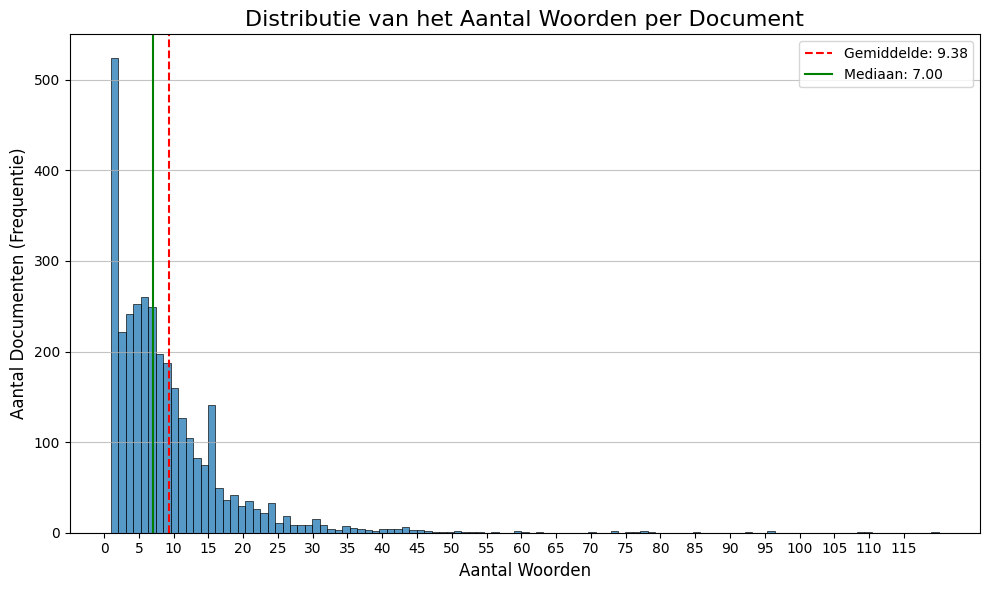

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# 1. Bereken het aantal woorden voor elk document
word_counts = [len(doc.split()) for doc in docs]

# 2. Bereken de statistieken
average_words = np.mean(word_counts)
median_words = np.median(word_counts)
min_words = np.min(word_counts)
max_words = np.max(word_counts)

# 3. Print de statistieken
print("Statistieken van Woordenaantal:")
print(f"- Gemiddelde (Average): {average_words}")
print(f"- Mediaan (Median): {median_words}")
print(f"- Minimum (Min): {min_words}")
print(f"- Maximum (Max): {max_words}")


# 4. Maak de plot
plt.figure(figsize=(10, 6))
sns.histplot(word_counts)
plt.title('Distributie van het Aantal Woorden per Document', fontsize=16)
plt.xlabel('Aantal Woorden', fontsize=12)
plt.ylabel('Aantal Documenten (Frequentie)', fontsize=12)

# --- TOEGEVOEGDE CODE OM MEER X-TICKS TE MAKEN ---
# Stel nieuwe ticks in van het minimum tot het maximum aantal woorden, met een stapgrootte van 2
plt.xticks(np.arange(0, max_words, step=5))
# --- EINDE TOEGEVOEGDE CODE ---

# Voeg lijnen voor gemiddelde en mediaan toe aan de plot
plt.axvline(average_words, color='r', linestyle='--', label=f'Gemiddelde: {average_words:.2f}')
plt.axvline(median_words, color='g', linestyle='-', label=f'Mediaan: {median_words:.2f}')

plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

# Sla de figuur op
plt.savefig('word_count_distribution_more_x_ticks.png')

# Toon de plot (optioneel, in omgevingen zoals Jupyter)
# plt.show()

Terug reverse enginerering voor meer context

Nu veel te veel docs met een enkel woord






Trying regex to get the sentances around the single words in embedded lies, first let create a more refined dataset to drop alot of the columns


Check zou moeten kloppen maar we kijken later verder

REGEX for full sentances around the embedded lies, ff nieuwe dataset met minder troep

In [44]:
# Selecteer relevante kolommen
keep_cols = [
    "Participant_id",
    "Event",
    "False_event",
    "False_event_num_words",
    "merged_lies",
    "EL_num_words",
    "is_positive_gain"
]

# Verzamel dynamisch kolommen van ingebedde leugens
embedded_cols = [
    c for c in df_filtered.columns 
    if c.startswith("Embedded_lies_") and not any(x in c for x in ["_deceptiveness", "_centrality", "_source"])
]

# Combineer alle kolommen
final_cols = keep_cols + embedded_cols

# Maak een nieuwe DataFrame met alleen de geselecteerde kolommen
df_lies = df_filtered[final_cols].copy()

# Maak een 'long format' dataframe
df_long = df_lies.melt(
    id_vars=keep_cols,
    value_vars=embedded_cols,
    var_name="embedded_lie_num",
    value_name="embedded_lie"
)

# Verwijder lege rijen en reset de index
df_long.dropna(subset=["embedded_lie"], inplace=True)
df_long.reset_index(drop=True, inplace=True)

# Haal het nummer uit de kolomnaam en converteer naar integer
df_long["embedded_lie_num"] = df_long["embedded_lie_num"].str.extract(r"(\d+)").astype(int)

# Sorteer en verwijder overbodige kolom
df_long.sort_values(by=["Participant_id", "Event", "embedded_lie_num"], inplace=True)
df_long.drop(columns='merged_lies', inplace=True)
df_long.reset_index(drop=True, inplace=True)

df_long['EL_num_words_single'] = df_long['embedded_lie'].apply(lambda x: len(str(x).split()))


In [57]:
df_long['is_in_false_event'] = df_long.apply(
    lambda row: str(row['embedded_lie']) in str(row['False_event']), axis=1
)

# Tel het aantal rijen waar de embedded lie niet in de false event voorkomt
not_found_count = len(df_long[df_long['is_in_false_event'] == False])

# Verwijder de rijen waar de embedded_lie niet in de False_event voorkomt
df_long_clean = df_long[df_long['is_in_false_event'] == True].copy()

# Print het aantal rijen in de nieuwe, opgeschoonde DataFrame
print(f"Aantal rijen in de oorspronkelijke DataFrame: {len(df_long)}")
print(f"Aantal rijen in de opgeschoonde DataFrame: {len(df_long_clean)}")

# Optioneel: Verwijder de tijdelijke controlekolom
df_long_clean.drop(columns='is_in_false_event', inplace=True)


Aantal rijen in de oorspronkelijke DataFrame: 3256
Aantal rijen in de opgeschoonde DataFrame: 3006


Woordtelling vergelijking na lengtecontrole:
       EL_num_words_single  enriched_lie_word_count_controlled
count          3006.000000                         3006.000000
mean              9.023952                           25.491351
std               8.425820                           27.846784
min               1.000000                            1.000000
25%               4.000000                            7.000000
50%               7.000000                           12.000000
75%              11.000000                           31.000000
max             110.000000                          100.000000


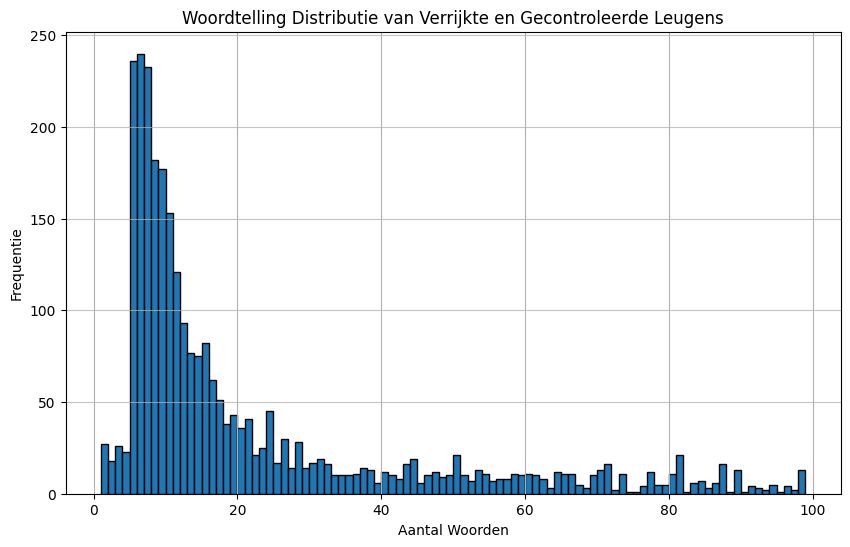

In [71]:
import re

def enrich_lie_with_control(row, min_words=5, max_words=100):
    """
    Verrijkt een korte 'embedded_lie' met context uit 'False_event' en stuurt de lengte.

    Args:
        row (pd.Series): Een rij uit de DataFrame.
        min_words (int): Minimale woordtelling voor de output.
        max_words (int): Maximale woordtelling voor de output.

    Returns:
        str: De oorspronkelijke leugen of de verrijkte zin met gecontroleerde lengte.
    """
    embedded_lie = str(row['embedded_lie']).strip()
    false_event = str(row['False_event']).strip()
    
    # Woordtelling van de oorspronkelijke leugen
    original_word_count = len(embedded_lie.split())
    
    # 1. Als de oorspronkelijke leugen al binnen het gewenste bereik valt, houd hem.
    if min_words <= original_word_count <= max_words:
        return embedded_lie
    
    # 2. Als de leugen te kort is, probeer hem te verrijken.
    if original_word_count < min_words:
        # Zoek de zin die de leugen bevat.
        match = re.search(
            f'([A-Z].*?{re.escape(embedded_lie)}.*?[.!?])', 
            false_event, 
            re.IGNORECASE
        )
        if match:
            enriched_lie = match.group(0).strip()
            # Als de verrijkte zin te lang is, kort hem in tot 50 woorden.
            enriched_word_count = len(enriched_lie.split())
            if enriched_word_count > max_words:
                words = enriched_lie.split()
                return ' '.join(words[:max_words])
            else:
                return enriched_lie
        
        # Val terug op de oorspronkelijke leugen als er geen verrijking mogelijk is.
        return embedded_lie

    # 3. Als de oorspronkelijke leugen te lang is, kort hem dan in tot 50 woorden.
    if original_word_count > max_words:
        words = embedded_lie.split()
        return ' '.join(words[:max_words])

# Pas de functie toe op de DataFrame
df_long_clean['enriched_lie'] = df_long_clean.apply(
    lambda row: enrich_lie_with_control(row), axis=1
)

# Bereken de woordtelling voor de nieuwe kolom ter controle
df_long_clean['enriched_lie_word_count_controlled'] = df_long_clean['enriched_lie'].str.split().str.len()

# Visuele controle met een beschrijvingstabel en een histogram om de nieuwe distributie te tonen
print("Woordtelling vergelijking na lengtecontrole:")
print(df_long_clean[['EL_num_words_single', 'enriched_lie_word_count_controlled']].describe())

df_long_clean['enriched_lie_word_count_controlled'].hist(bins=range(1, 100), figsize=(10, 6), edgecolor='black')
plt.title('Woordtelling Distributie van Verrijkte en Gecontroleerde Leugens')
plt.xlabel('Aantal Woorden')
plt.ylabel('Frequentie')
plt.grid(axis='y', alpha=0.75)
plt.show()